                      Method    Condition  Dice   IoU Sensitivity Specificity Precision AUPRC
Classical (Adaptive + Morph)          Raw 0.641 0.472       0.711       0.878     0.587     —
Classical (Adaptive + Morph) Preprocessed 0.679 0.514       0.697       0.915     0.665     —
                       U-Net          Raw 0.774 0.635       0.759       0.956     0.796 0.866
                   Attention          Raw 0.773 0.633       0.763       0.953     0.789 0.865
                    Residual          Raw 0.780 0.642       0.741       0.965     0.829 0.872
                          SE          Raw 0.772 0.631       0.759       0.954     0.791 0.861
                   Att + Res          Raw 0.780 0.642       0.743       0.964     0.826 0.871
                       U-Net Preprocessed 0.770 0.629       0.750       0.957     0.798 0.862
                   Attention Preprocessed 0.768 0.626       0.762       0.951     0.779 0.862
                    Residual Preprocessed 0.776 0.636       

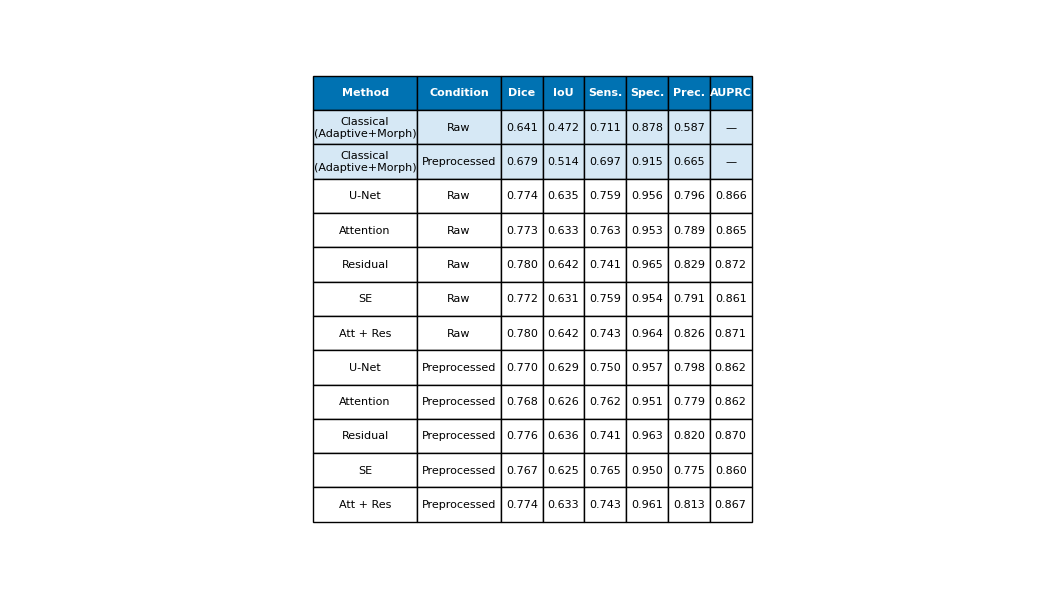

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Load and parse data ----
classical = pd.read_csv('../figures/ROSE-1 SVC.csv', keep_default_na=False)
flex = pd.read_csv('../figures/ROSE-1 SVC Flex-UNet.csv')

# Parse "mean±std" strings in the FlexUNet file
metric_cols = ['dice', 'iou', 'sensitivity', 'specificity', 'precision', 'auprc']
for col in metric_cols:
    split = flex[col].str.split('±', expand=True)
    flex[f'{col}_mean'] = split[0].astype(float)
    flex[f'{col}_std'] = split[1].astype(float)

# Best classical method per condition (by Dice)
best_classical = (
    classical.sort_values('Dice', ascending=False)
    .drop_duplicates('Preprocessing')
    .set_index('Preprocessing')
)

variant_order = ['unet', 'attention_unet', 'res_unet', 'se_unet', 'att_res_unet']
variant_labels = {'unet': 'U-Net', 'attention_unet': 'Attention', 'res_unet': 'Residual',
                   'se_unet': 'SE', 'att_res_unet': 'Att + Res'}

# ---- Build unified table ----
rows = []

for cond_name, cond_key in [('Raw', 'None'), ('Preprocessed', 'CLAHE + Median')]:
    c = best_classical.loc[cond_key]
    rows.append({
        'Method': f'Classical ({c["Method"]})',
        'Condition': cond_name,
        'Dice': f'{c["Dice"]:.3f}',
        'IoU': f'{c["IoU"]:.3f}',
        'Sensitivity': f'{c["Sensitivity"]:.3f}',
        'Specificity': f'{c["Specificity"]:.3f}',
        'Precision': f'{c["Precision"]:.3f}',
        'AUPRC': '—',
    })
    
for cond_name, cond_key in [('Raw', 'raw'), ('Preprocessed', 'preprocessed')]:
    for v in variant_order:
        r = flex[(flex.condition == cond_key) & (flex.model == v)].iloc[0]
        rows.append({
            'Method': variant_labels[v],
            'Condition': cond_name,
            'Dice': f'{r["dice_mean"]:.3f}',
            'IoU': f'{r["iou_mean"]:.3f}',
            'Sensitivity': f'{r["sensitivity_mean"]:.3f}',
            'Specificity': f'{r["specificity_mean"]:.3f}',
            'Precision': f'{r["precision_mean"]:.3f}',
            'AUPRC': f'{r["auprc_mean"]:.3f}',
        })

table_df = pd.DataFrame(rows)
table_df.to_csv('../figures/summary_metrics_table.csv', index=False)
print(table_df.to_string(index=False))

# Shorten the classical label so it doesn't get clipped in the table image
table_df['Method'] = table_df['Method'].replace(
    {'Classical (Adaptive + Morph)': 'Classical\n(Adaptive+Morph)'}
)

# ---- Rename columns for a cleaner poster table ----
table_df = table_df.rename(columns={
    'Sensitivity': 'Sens.',
    'Specificity': 'Spec.',
    'Precision': 'Prec.'
})

# Shorten the classical label
table_df['Method'] = table_df['Method'].replace(
    {'Classical (Adaptive + Morph)': 'Classical\n(Adaptive+Morph)'}
)

# ---- Render as an image for the poster ----
fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(table_df) + 0.8))
ax.axis('off')

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[
        0.10,  # Method
        0.08,  # Condition
        0.04,  # Dice
        0.04,  # IoU
        0.04,  # Sens.
        0.04,  # Spec.
        0.04,  # Prec.
        0.04   # AUPRC
    ],
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.6)

# Style header row
for j in range(len(table_df.columns)):
    cell = tbl[0, j]
    cell.set_facecolor('#0072B2')
    cell.set_text_props(color='white', weight='bold')

# Shade classical rows
for i in range(1, 3):
    for j in range(len(table_df.columns)):
        tbl[i, j].set_facecolor('#D6E8F5')

plt.tight_layout(pad=0.2)
plt.savefig('../figures/summary_metrics_table.png', dpi=300, bbox_inches='tight')
plt.show()

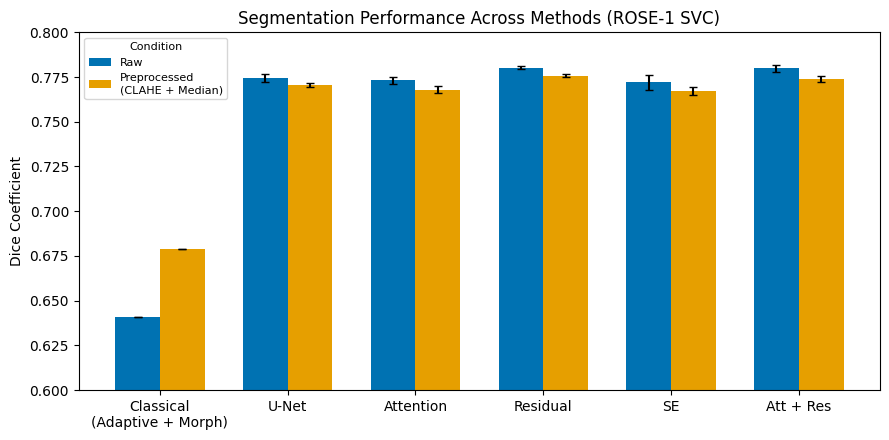

                       Method  Raw Dice  Preprocessed Dice
Classical\n(Adaptive + Morph)    0.6411             0.6787
                        U-Net    0.7744             0.7704
                    Attention    0.7732             0.7680
                     Residual    0.7802             0.7758
                           SE    0.7720             0.7672
                    Att + Res    0.7799             0.7737


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Load and parse data ----
classical = pd.read_csv('../figures/ROSE-1 SVC.csv', keep_default_na=False)
flex = pd.read_csv('../figures/ROSE-1 SVC Flex-UNet.csv')

# Parse "mean±std" strings in the FlexUNet file into separate columns
for col in ['dice', 'iou', 'sensitivity', 'specificity', 'precision', 'auprc']:
    split = flex[col].str.split('±', expand=True)
    flex[f'{col}_mean'] = split[0].astype(float)
    flex[f'{col}_std'] = split[1].astype(float)

# Pick best classical method per condition (highest Dice)
best_classical = (
    classical.sort_values('Dice', ascending=False)
    .drop_duplicates('Preprocessing')
    .set_index('Preprocessing')
)

classical_raw = best_classical.loc['None', 'Dice']
classical_prep = best_classical.loc['CLAHE + Median', 'Dice']
best_classical_name = best_classical.loc['None', 'Method']  # assumes same method wins both

# ---- Build unified table ----
variant_order = ['unet', 'attention_unet', 'res_unet', 'se_unet', 'att_res_unet']
variant_labels = ['U-Net', 'Attention', 'Residual', 'SE', 'Att + Res']

labels = [f'Classical\n({best_classical_name})'] + variant_labels

raw_means = [classical_raw] + [
    flex[(flex.condition == 'raw') & (flex.model == v)]['dice_mean'].values[0]
    for v in variant_order
]
raw_stds = [0] + [
    flex[(flex.condition == 'raw') & (flex.model == v)]['dice_std'].values[0]
    for v in variant_order
]

prep_means = [classical_prep] + [
    flex[(flex.condition == 'preprocessed') & (flex.model == v)]['dice_mean'].values[0]
    for v in variant_order
]
prep_stds = [0] + [
    flex[(flex.condition == 'preprocessed') & (flex.model == v)]['dice_std'].values[0]
    for v in variant_order
]

# ---- Plot ----
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(
    x - width/2,
    raw_means,
    width,
    yerr=raw_stds,
    capsize=3,
    label='Raw',
    color='#0072B2'
)

ax.bar(
    x + width/2,
    prep_means,
    width,
    yerr=prep_stds,
    capsize=3,
    label='Preprocessed\n(CLAHE + Median)',
    color='#E69F00'
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Dice Coefficient')
ax.set_ylim(0.6, 0.8)
ax.set_title('Segmentation Performance Across Methods (ROSE-1 SVC)')

# Legend inside the plot
ax.legend(
    title='Condition',
    loc='upper left',
    frameon=True,
    fontsize=8,
    title_fontsize=8
)

plt.tight_layout()
plt.savefig('../figures/all_methods_comparison.png', dpi=300)
plt.show()

# ---- Print summary table for reference ----
summary = pd.DataFrame({
    'Method': labels,
    'Raw Dice': raw_means,
    'Preprocessed Dice': prep_means,
})

print(summary.to_string(index=False))

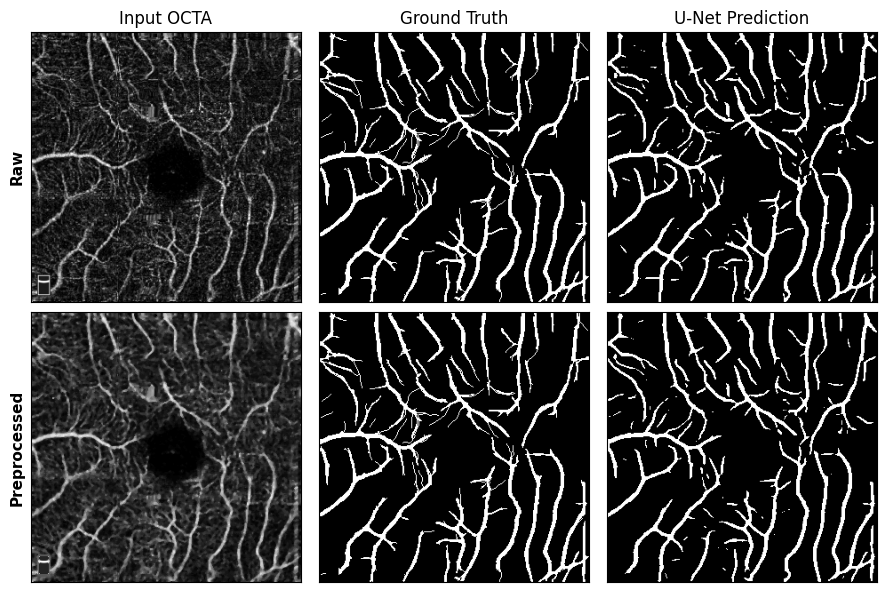

In [5]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

from model import FlexUNet  # FlexUNet with all flags off is structurally identical to the old plain UNet
from dataset import OCTADataset, get_kfold_splits, create_datasets

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Build path lists for raw ROSE-1 SVC ----
raw_root = '/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1/SVC'
raw_train_imgs = sorted(glob.glob(f'{raw_root}/train/img/*'))
raw_train_masks = sorted(glob.glob(f'{raw_root}/train/gt/*'))
raw_test_imgs = sorted(glob.glob(f'{raw_root}/test/img/*'))
raw_test_masks = sorted(glob.glob(f'{raw_root}/test/gt/*'))

# ---- Build path lists for preprocessed ROSE-1 SVC ----
# Preprocessing only touches images; masks are unchanged, so reuse the raw masks.
prep_root = '/users/egottfri/code/octa-segmentation/data/preprocessed/SVC'
prep_train_imgs = sorted(glob.glob(f'{prep_root}/train/img/*'))
prep_train_masks = raw_train_masks
prep_test_imgs = sorted(glob.glob(f'{prep_root}/test/img/*'))
prep_test_masks = raw_test_masks

# ---- Rebuild fold 1 splits (same random_state=42 used originally) ----
raw_splits = get_kfold_splits(raw_train_imgs, raw_train_masks, raw_test_imgs, raw_test_masks)
prep_splits = get_kfold_splits(prep_train_imgs, prep_train_masks, prep_test_imgs, prep_test_masks)

_, _, test_dataset_raw = create_datasets(raw_splits['folds'][0], raw_splits['test'])
_, _, test_dataset_prep = create_datasets(prep_splits['folds'][0], prep_splits['test'])

img_raw, gt_raw = test_dataset_raw[0]
img_prep, gt_prep = test_dataset_prep[0]

# ---- Load checkpoints ----
# These checkpoints predate the ConvBlock refactor: old keys look like
# "enc1.double_conv.0.weight", new FlexUNet expects "enc1.conv.double_conv.0.weight"
# (enc/dec/bottleneck wrap DoubleConv inside ConvBlock now; up/final are unchanged).
def remap_old_state_dict(old_sd):
    new_sd = {}
    for k, v in old_sd.items():
        if '.double_conv.' in k and not k.startswith(('up', 'final')):
            prefix, rest = k.split('.double_conv.', 1)
            new_sd[f'{prefix}.conv.double_conv.{rest}'] = v
        else:
            new_sd[k] = v
    return new_sd

def load_plain_unet(ckpt_path):
    model = FlexUNet(attention=False, residual=False, se=False).to(device)
    state_dict = torch.load(ckpt_path, map_location=device)
    state_dict = remap_old_state_dict(state_dict)
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model

model_raw = load_plain_unet('../results/unet_svc_raw/best_model_fold1.pth')
model_prep = load_plain_unet('../results/unet_svc_preprocessed/best_model_fold1.pth')

# ---- Run predictions ----
def predict(model, img):
    with torch.no_grad():
        inp = img.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(inp)).squeeze().cpu().numpy()
        return (pred > 0.5).astype(float)

pred_raw = predict(model_raw, img_raw)
pred_prep = predict(model_prep, img_prep)

# ---- Plot ----
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

rows = [
    ('Raw', img_raw, gt_raw, pred_raw),
    ('Preprocessed', img_prep, gt_prep, pred_prep),
]

for i, (row_label, img, gt, pred) in enumerate(rows):
    img_np = img.squeeze().cpu().numpy() if torch.is_tensor(img) else np.array(img).squeeze()
    gt_np = gt.squeeze().cpu().numpy() if torch.is_tensor(gt) else np.array(gt).squeeze()

    axes[i, 0].imshow(img_np, cmap='gray')
    axes[i, 1].imshow(gt_np, cmap='gray')
    axes[i, 2].imshow(pred, cmap='gray')

    axes[i, 0].set_ylabel(row_label, fontsize=11, fontweight='bold')

    for j in range(3):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

axes[0, 0].set_title('Input OCTA')
axes[0, 1].set_title('Ground Truth')
axes[0, 2].set_title('U-Net Prediction')

plt.tight_layout()
plt.savefig('../figures/example_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

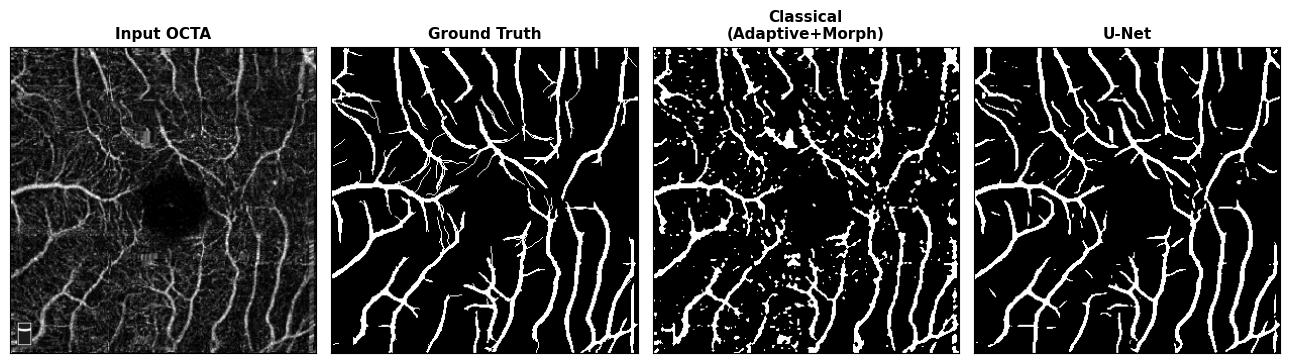

In [21]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import glob
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from model import FlexUNet
from classical_baseline import segment_adaptive  # TODO: confirm exact import name/signature
from dataset import get_kfold_splits, create_datasets

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Rebuild raw test set (U-Net's best condition) ----
raw_root = '/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1/SVC'
raw_train_imgs = sorted(glob.glob(f'{raw_root}/train/img/*'))
raw_train_masks = sorted(glob.glob(f'{raw_root}/train/gt/*'))
raw_test_imgs = sorted(glob.glob(f'{raw_root}/test/img/*'))
raw_test_masks = sorted(glob.glob(f'{raw_root}/test/gt/*'))

raw_splits = get_kfold_splits(raw_train_imgs, raw_train_masks, raw_test_imgs, raw_test_masks)
_, _, test_dataset_raw = create_datasets(raw_splits['folds'][0], raw_splits['test'])

# ---- Preprocessed test images (classical's best condition) ----
prep_root = '/users/egottfri/code/octa-segmentation/data/preprocessed/SVC'
prep_test_imgs = sorted(glob.glob(f'{prep_root}/test/img/*'))

# ---- Load U-Net (raw-trained) ----
def remap_old_state_dict(old_sd):
    new_sd = {}
    for k, v in old_sd.items():
        if '.double_conv.' in k and not k.startswith(('up', 'final')):
            prefix, rest = k.split('.double_conv.', 1)
            new_sd[f'{prefix}.conv.double_conv.{rest}'] = v
        else:
            new_sd[k] = v
    return new_sd

model = FlexUNet(attention=False, residual=False, se=False).to(device)
state_dict = torch.load('../results/unet_svc_raw/best_model_fold1.pth', map_location=device)
model.load_state_dict(remap_old_state_dict(state_dict), strict=True)
model.eval()

def predict_unet(img_tensor):
    with torch.no_grad():
        inp = img_tensor.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(inp)).squeeze().cpu().numpy()
        return (pred > 0.5).astype(float)

# ---- Classical prediction (best params: block=101, C=-30, morph on) ----
def predict_classical(prep_img_path):
    img = cv2.imread(prep_img_path, cv2.IMREAD_GRAYSCALE)
    pred = segment_adaptive(img, block_size=101, offset_c=-30, clip=None, tile=None, use_morph=True)
    return pred

# ---- Build figure: 1 test image, stages shown horizontally ----
col_labels = ['Input OCTA', 'Ground Truth', 'Classical\n(Adaptive+Morph)', 'U-Net']

img_tensor, gt_tensor = test_dataset_raw[0]
img_np = img_tensor.squeeze().cpu().numpy() if torch.is_tensor(img_tensor) else np.array(img_tensor).squeeze()
gt_np = gt_tensor.squeeze().cpu().numpy() if torch.is_tensor(gt_tensor) else np.array(gt_tensor).squeeze()

pred_classical = predict_classical(prep_test_imgs[0])
pred_unet = predict_unet(img_tensor)

panels = [img_np, gt_np, pred_classical, pred_unet]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, panel, label in zip(axes, panels, col_labels):
    ax.imshow(panel, cmap='gray')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('../figures/classical_vs_unet_qualitative.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import h5py
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

from model import FlexUNet

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Load one ARIAS subject ----
# TODO: pick a clean subject (avoid the flagged missing-eye / corrupted IDs in your notes)
arias_path = '/oscar/data/jlee123/procdata/adp/22-retina-arias-y1/A-segment/SUBJECT-YR/scan-p1a.h5'

with h5py.File(arias_path, 'r') as f:
    octa = f['octa'][:]        # (512, 512, 496)
    lyr = f['r1/lyr'][:]       # layer codes, same shape

svc_mask = (lyr >= 2) & (lyr <= 6)
svc_projection = np.max(octa * svc_mask, axis=2)  # en face max projection over SVC slab

# ---- Preprocess for model input ----
# Model was trained on 304x304 ROSE-1 images; resize + normalize to match roughly.
img_resized = cv2.resize(svc_projection, (304, 304))
img_norm = (img_resized - img_resized.min()) / (img_resized.max() - img_resized.min() + 1e-8)
img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# ---- Load model (raw-trained U-Net; only checkpoint currently available) ----
def remap_old_state_dict(old_sd):
    new_sd = {}
    for k, v in old_sd.items():
        if '.double_conv.' in k and not k.startswith(('up', 'final')):
            prefix, rest = k.split('.double_conv.', 1)
            new_sd[f'{prefix}.conv.double_conv.{rest}'] = v
        else:
            new_sd[k] = v
    return new_sd

model = FlexUNet(attention=False, residual=False, se=False).to(device)
state_dict = torch.load('../results/unet_svc_raw/best_model_fold1.pth', map_location=device)
model.load_state_dict(remap_old_state_dict(state_dict), strict=True)
model.eval()

with torch.no_grad():
    pred = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
    pred_mask = (pred > 0.5).astype(np.uint8)

# ---- Build overlay: predicted vessels in color on top of grayscale input ----
base_rgb = cv2.cvtColor((img_norm * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay = base_rgb.copy()
overlay[pred_mask == 1] = [255, 80, 80]  # highlight predicted vessels in red
blended = cv2.addWeighted(base_rgb, 0.5, overlay, 0.5, 0)

# ---- Plot: input | predicted mask | overlay ----
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(img_norm, cmap='gray')
axes[0].set_title('ARIAS SVC En Face\n(Heidelberg Spectralis)')
axes[1].imshow(pred_mask, cmap='gray')
axes[1].set_title('Predicted Vessel Mask\n(model trained on ROSE-1, no fine-tuning)')
axes[2].imshow(blended)
axes[2].set_title('Overlay')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('../figures/arias_transfer_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/oscar/data/jlee123/procdata/adp/22-retina-arias-y1/A-segment/SUBJECT-YR/scan-p1a.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [2]:
import os

base = '/oscar/data/jlee123/procdata/adp/22-retina-arias-y1/A-segment'
subjects = sorted(os.listdir(base))
print(subjects[:20])
print(f'Total: {len(subjects)}')

['101-1003-y1', '101-1004-y1', '101-1006-y1', '101-1007-y1', '101-1008-y1', '101-1010-y1', '101-1011-y1', '101-1012-y1', '101-1017-y1', '101-1018-y1', '101-1019-y1', '101-1020-y1', '101-1026-y1', '101-1032-y1', '101-1055-y1', '101-1056-y1', '101-1065-y1', '101-1068-y1', '101-1070-y1', '101-1071-y1']
Total: 42


Opening file...
Volume shape: (512, 512, 496)
Projection built.
Loading model...
Running prediction...


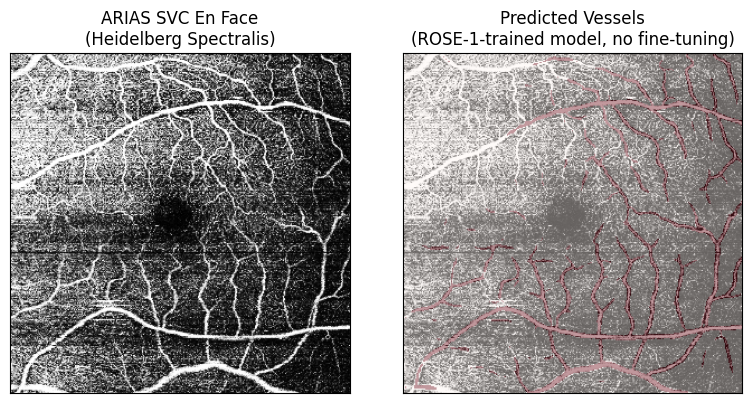

Done.


In [4]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import h5py
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

from model import FlexUNet

device = 'cuda' if torch.cuda.is_available() else 'cpu'
arias_path = '/oscar/data/jlee123/procdata/adp/22-retina-arias-y1/A-segment/101-1003-y1/473-p1a.h5'

# ---- Step 1: build the SVC en face projection, one B-scan at a time ----
# This avoids ever holding the full (512, 512, 496) volume x2 in memory at once.
print('Opening file...')
with h5py.File(arias_path, 'r') as f:
    octa_ds = f['octa']
    lyr_ds = f['r1/lyr']
    height, width, depth = octa_ds.shape
    print(f'Volume shape: {octa_ds.shape}')

    svc_projection = np.zeros((height, width), dtype=np.float32)
    for z in range(depth):
        octa_slice = octa_ds[:, :, z].astype(np.float32)
        lyr_slice = lyr_ds[:, :, z]
        mask_slice = (lyr_slice >= 2) & (lyr_slice <= 6)
        svc_projection = np.maximum(svc_projection, np.where(mask_slice, octa_slice, 0))

print('Projection built.')

# ---- Step 2: prep for model input ----
img_resized = cv2.resize(svc_projection, (304, 304))
img_norm = (img_resized - img_resized.min()) / (img_resized.max() - img_resized.min() + 1e-8)
img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# ---- Step 3: load model ----
def remap_old_state_dict(old_sd):
    new_sd = {}
    for k, v in old_sd.items():
        if '.double_conv.' in k and not k.startswith(('up', 'final')):
            prefix, rest = k.split('.double_conv.', 1)
            new_sd[f'{prefix}.conv.double_conv.{rest}'] = v
        else:
            new_sd[k] = v
    return new_sd

print('Loading model...')
model = FlexUNet(attention=False, residual=False, se=False).to(device)
state_dict = torch.load('../results/unet_svc_raw/best_model_fold1.pth', map_location=device)
model.load_state_dict(remap_old_state_dict(state_dict), strict=True)
model.eval()

# ---- Step 4: predict ----
print('Running prediction...')
with torch.no_grad():
    pred = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
    pred_mask = (pred > 0.5).astype(np.uint8)

# ---- Step 5: simple two-panel output ----
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_norm, cmap='gray')
axes[0].set_title('ARIAS SVC En Face\n(Heidelberg Spectralis)')
axes[1].imshow(img_norm, cmap='gray')
axes[1].imshow(pred_mask, cmap='Reds', alpha=0.4)
axes[1].set_title('Predicted Vessels\n(ROSE-1-trained model, no fine-tuning)')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('../figures/arias_transfer_overlay.png', dpi=300, bbox_inches='tight')
plt.show()
print('Done.')